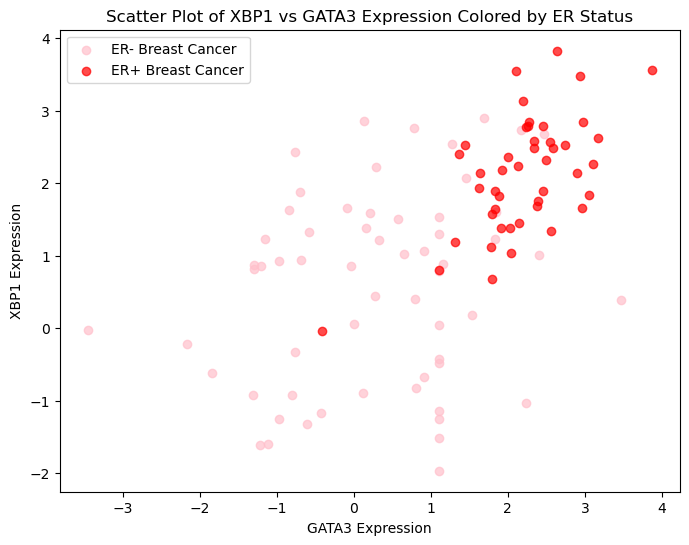

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data files
expression_data = pd.read_csv('filtered.tsv', sep='\t')
labels = pd.read_csv('class.tsv', sep='\t', header=None)
gene_info = pd.read_csv('columns.tsv', sep='\t',comment='#')

# Extract the corresponding gene IDs for GATA3 and XBP1
gata3_gene_id = str(gene_info.loc[gene_info['GeneSymbol'] == 'GATA3', 'ID'].values[0])
xbp1_gene_id = str(gene_info.loc[gene_info['GeneSymbol'] == 'XBP1', 'ID'].values[0])

# Prepare the column names by adding a space prefix
gata3_column = " " + gata3_gene_id
xbp1_column = " " + xbp1_gene_id

# Retrieve the expression values for GATA3 and XBP1
gata3_expr = expression_data[gata3_column]
xbp1_expr = expression_data[xbp1_column]

# Retrieve class labels
class_labels = labels.iloc[:, 0]

# Boolean masks for the two classes (ER- and ER+)
er_negative = (class_labels == 0)
er_positive = (class_labels == 1)

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(gata3_expr[er_negative], xbp1_expr[er_negative], color='pink', alpha=0.7, label='ER- Breast Cancer')
plt.scatter(gata3_expr[er_positive], xbp1_expr[er_positive], color='red', alpha=0.7, label='ER+ Breast Cancer')

# Label the axes and the plot
plt.xlabel('GATA3 Expression')
plt.ylabel('XBP1 Expression')
plt.title('Scatter Plot of XBP1 vs GATA3 Expression Colored by ER Status')
plt.legend()
plt.show()


B part

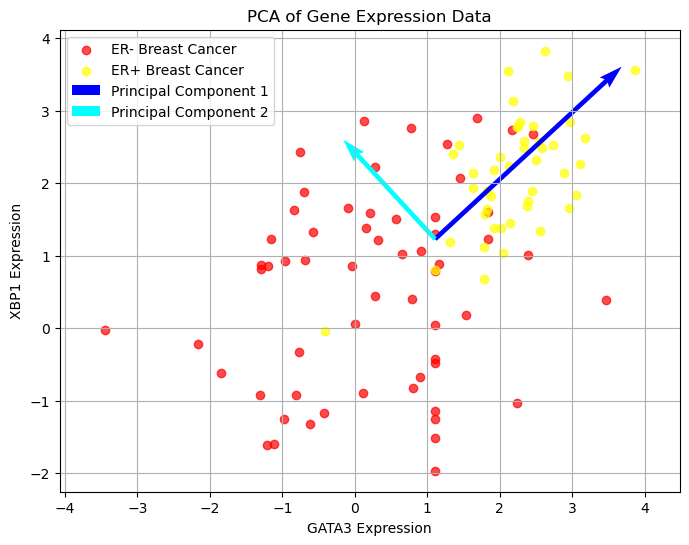

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Combine selected gene expression values into a 2D matrix
expression_matrix = np.vstack((gata3_expr, xbp1_expr)).T

# Center the data (subtract the mean)
mean_vector = np.mean(expression_matrix, axis=0)
centered_matrix = expression_matrix - mean_vector

# Perform PCA from scratch
covariance_matrix = np.cov(centered_matrix.T)
eig_vals, eig_vecs = np.linalg.eig(covariance_matrix)

# Sort eigenvectors by descending eigenvalues
sorted_indices = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_indices]
eig_vecs = eig_vecs[:, sorted_indices]

# Boolean masks for the two classes
negative_mask = (class_labels == 0)
positive_mask = (class_labels == 1)

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(gata3_expr[negative_mask], xbp1_expr[negative_mask], 
            color='red', alpha=0.7, label='ER- Breast Cancer')
plt.scatter(gata3_expr[positive_mask], xbp1_expr[positive_mask], 
            color='yellow', alpha=0.7, label='ER+ Breast Cancer')

# Label axes
plt.xlabel('GATA3 Expression')
plt.ylabel('XBP1 Expression')
plt.title('PCA of Gene Expression Data')

# Plot eigenvectors (principal components)
for i in range(2):
    direction = eig_vecs[:, i]
    magnitude = np.sqrt(eig_vals[i]) * 2  # Scaling for visualization
    plt.quiver(mean_vector[0], mean_vector[1],
               direction[0] * magnitude, direction[1] * magnitude,
               angles='xy', scale_units='xy', scale=1,
               color='blue' if i == 0 else 'cyan',
               label=f'Principal Component {i+1}')

plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()


part c

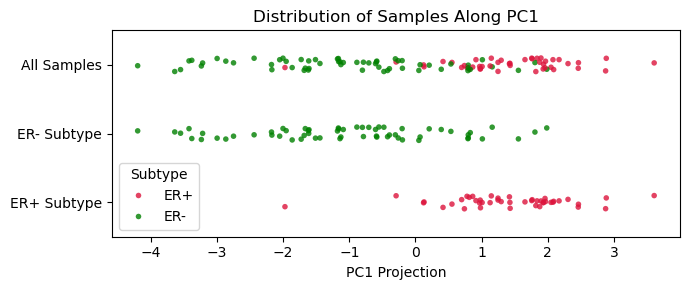

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project centered data onto the first principal component
pc1_scores = centered_matrix @ eig_vecs[:, 0]

# Map numeric labels to class names
label_names = class_labels.map({0: 'ER-', 1: 'ER+'})
projection_df = pd.DataFrame({'PC1_Score': pc1_scores, 'Subtype': label_names})

# Create grouping labels for All, ER-, and ER+
group_all = projection_df.copy()
group_all['Category'] = 'All Samples'

group_er_neg = projection_df[label_names == 'ER-'].copy()
group_er_neg['Category'] = 'ER- Subtype'

group_er_pos = projection_df[label_names == 'ER+'].copy()
group_er_pos['Category'] = 'ER+ Subtype'

# Merge all groups into a single DataFrame for plotting
merged_df = pd.concat([group_all, group_er_neg, group_er_pos], ignore_index=True)

# Plotting PC1 projections across groups
plt.figure(figsize=(7, 3))
sns.stripplot(
    data=merged_df,
    x='PC1_Score',
    y='Category',
    hue='Subtype',
    palette={'ER-': 'green', 'ER+': 'crimson'},
    dodge=False,
    jitter=0.1,
    size=4,
    alpha=0.8,
    orient='h'
)

plt.xlabel('PC1 Projection')
plt.ylabel('')
plt.title('Distribution of Samples Along PC1')
plt.legend(title='Subtype')
plt.tight_layout()
plt.show()


part D

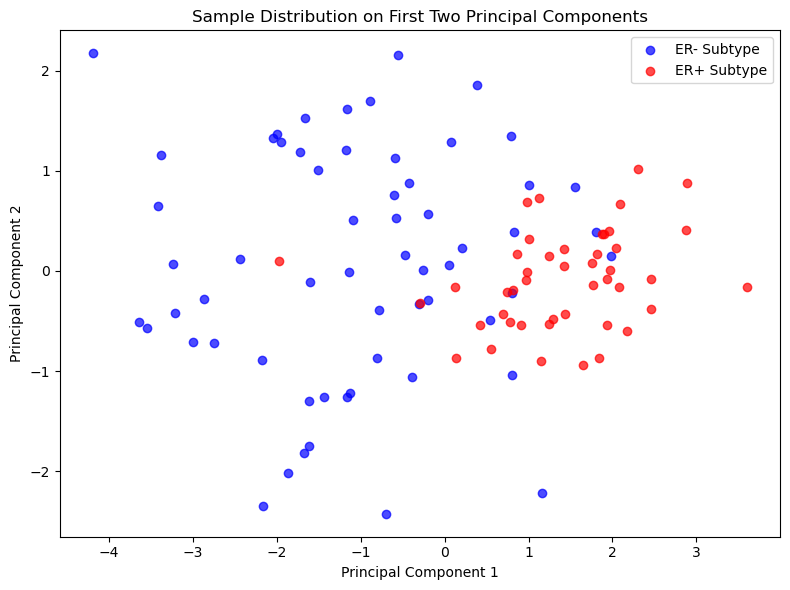

In [38]:
# Project the centered matrix onto the second principal component
proj_pc2 = centered_matrix @ eig_vecs[:, 1]

# Create masks for the two classes
mask_neg = (class_labels == 0)
mask_pos = (class_labels == 1)

# Create the scatter plot for PC1 vs. PC2
plt.figure(figsize=(8, 6))
plt.scatter(pc1_scores[mask_neg], proj_pc2[mask_neg], color='blue', label='ER- Subtype', alpha=0.7)
plt.scatter(pc1_scores[mask_pos], proj_pc2[mask_pos], color='red', label='ER+ Subtype', alpha=0.7)

# Labeling and formatting
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Sample Distribution on First Two Principal Components')
plt.legend()
plt.tight_layout()
plt.show()
